In [1]:
import json_loader.json_loader as json_loader
import utils.utils as utils
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore")

In [2]:
# segéd függévnyek
def data_clean(df_exercise_results, df_weight_measure, df_patients):
    """
    Előkészíti és egységesíti a bemeneti adatállományokat a későbbi elemzéshez.

    A függvény:
    - Egységesíti az oszlopneveket minden táblában ('ert_id', 'subject', 'id' → 'patient_id').
    - Átalakítja az időbélyeg mezőket datetime formátumra.
    - A súlyadatokat numerikus típussá konvertálja.
    - A születési dátumból kiszámolja a páciensek életkorát 2025. január 1-jére vonatkoztatva.

    Paraméterek:
        df_exercise_results (pd.DataFrame): A mozgásos aktivitás eredmények táblája.
        df_weight_measure (pd.DataFrame): A súlymérések táblája.
        df_patients (pd.DataFrame): A betegek törzsadatait tartalmazó tábla.

    Visszatérési érték:
        Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]: A három megtisztított és előkészített adatkeret.
    """

    # Oszlopnevek egységesítése: mindenhol legyen 'patient_id'
    if 'ert_id' in df_exercise_results.columns:
        df_exercise_results.rename(columns={'ert_id': 'patient_id'}, inplace=True)
    if 'subject' in df_weight_measure.columns:
        df_weight_measure.rename(columns={'subject': 'patient_id'}, inplace=True)
    if 'id' in df_patients.columns:
        df_patients.rename(columns={'id': 'patient_id'}, inplace=True)

    # Súlymérés: időbélyeg konvertálása és súly numerikussá tétele
    df_weight_measure["timestamp"] = pd.to_datetime(df_weight_measure["timestamp"])
    df_weight_measure["weight"] = pd.to_numeric(df_weight_measure["weight"], errors="coerce")

    # Betegek születési dátuma → kor kiszámítása (2025-01-01-hez viszonyítva)
    df_patients["birthDate"] = pd.to_datetime(df_patients["birthDate"], errors='coerce')
    df_patients["age"] = (pd.to_datetime("2025-01-01") - df_patients["birthDate"]).dt.days // 365
    # Korosztályokba sorolása
    df_patients["age_group"] = pd.cut(df_patients["age"], bins=[0, 30, 45, 60, 100], labels=["<30", "30-45", "45-60", "60+"])


    return df_exercise_results, df_weight_measure, df_patients

# Definiáljunk egy függvényt, amely resamle-zi az egyes betegek adatait heti (péntek éjfél)
def resample_weekly_weights(df_weight):
    """
    Átalakítja a súlyméréseket heti gyakoriságú idősorrá minden beteg esetében.

    A függvény egy olyan DataFrame-et vár, amely időbélyeggel és súlyértékkel rendelkező méréseket tartalmaz.
    A visszatérési érték egy olyan sorozat, amely hetente egy (péntek éjféli) súlyt tartalmaz:
    - Ha egy héten belül több mérés is van, akkor azok átlagolásra kerülnek.
    - Ha egy héten nincs mérés, akkor az utolsó ismert súlyértéket használja.

    Paraméterek:
        df_weight (pd.DataFrame): A bemeneti adatkeret, amelynek oszlopai között szerepel a 'timestamp' és a 'weight'.

    Visszatérési érték:
        pd.Series: Heti gyakoriságú (péntek éjféli) súlyértékeket tartalmazó időindexelt sorozat.
    """
   
    # Rendezés idő szerint, és az index beállítása időbélyegzőre
    df_weight = df_weight.sort_values("timestamp")
    df_weight.set_index("timestamp", inplace=True)

    # Átlagolás heti (péntek) gyakorisággal
    weekly = df_weight["weight"].resample("W-FRI").mean()

    # Töltse ki a hiányzó heteket az utolsó ismert értékkel
    weekly_filled = weekly.ffill()

    return weekly_filled

def df_weekly_exercise(df):
    """
    Kiszámítja a testsúly százalékos változását az első heti méréshez képest.

    A függvény minden páciens heti súlyadatait tartalmazó DataFrame-jét várja,
    és kiszámítja, hogy az egyes hetekben mért testsúly hogyan változott
    az első heti méréshez (1. hét) képest.

    Paraméterek:
        df (pd.DataFrame): Egy páciens heti súlyadatait tartalmazó adatkeret, 
                           amely tartalmazza a 'weekly_weight' és 'week_number' oszlopokat.

    Visszatérési érték:
        pd.DataFrame: Ugyanaz az adatkeret egy új 'weight_change_pct' oszloppal kiegészítve,
                      amely a súlyváltozást mutatja százalékban.
    """
    # Hét szerint rendezzük az adatokat
    df = df.sort_values("week_number")

    # Lekérjük az első heti súlyt (1. hét)
    initial_weight = df.loc[df["week_number"] == 1, "weekly_weight"].values[0]

    # Százalékos változás kiszámítása az első héthez viszonyítva
    df["weight_change_pct"] = (df["weekly_weight"] - initial_weight) / initial_weight * 100

    return df

def plot_weight_loss_by_group(data, group_col, title):
    """
    Megjeleníti a heti testsúlyváltozás alakulását csoportos bontásban (pl. nem, korcsoport szerint).

    A függvény egy vonaldiagramot készít, amely azt mutatja, hogy a páciensek testsúlya
    hogyan változott az első heti értékhez képest százalékosan, hetente.
    A különböző görbék egy kiválasztott csoportosító változó szerint (pl. nem, életkor) kerülnek szétbontásra.
    Az árnyékolás az egyes csoportokon belüli szórást (`ci="sd"`) mutatja.

    Paraméterek:
        data (pd.DataFrame): Az adatkeret, amely tartalmazza a heti súlyváltozást 
                             ('week_number', 'weight_change_pct') és a csoportosító változót.
        group_col (str): Az oszlop neve, amely alapján a csoportosított vonalak készülnek (pl. 'gender', 'age_group').
        title (str): A grafikon címe.

    Visszatérési érték:
        Nincs – a függvény ábrát jelenít meg.
    """
    # Új ábra létrehozása
    plt.figure(figsize=(10, 6))

    # Vonaldiagram csoportonként, szórással együtt
    sns.lineplot(data=data, x="week_number", y="weight_change_pct", hue=group_col, ci="sd", marker="o")

    # Nullaszint jelölése
    plt.axhline(0, color="gray", linestyle="--")

    # Tengelyfeliratok és cím
    plt.ylabel("Testsúlyváltozás (%)")
    plt.xlabel("Hét sorszáma")
    plt.title(title)

    # Jelmagyarázat és stílus
    plt.legend(title=group_col)
    plt.grid(True)
    plt.tight_layout()

    # Ábra megjelenítése
    plt.show()

def plot_weight_loss_by_initial_weight_group(df):
    """
    Kirajzolja a heti testsúlyváltozás alakulását a kiindulási testsúly alapján csoportosítva.
    
    A súlycsoportok a valós eloszlás kvartilisei alapján kerülnek kialakításra:
    <85 kg, 85–108 kg, 108–141 kg, 141+ kg.
    """
    # Első heti súly lekérése
    initial_weights = (
        df[df["week_number"] == 1][["patient_id", "weekly_weight"]]
        .rename(columns={"weekly_weight": "initial_weight"})
    )
    df = df.merge(initial_weights, on="patient_id", how="left")

    # Kvartilis alapú csoportosítás
    bins = [0, 85, 108, 141, 300]
    labels = ["<85 kg", "85–108 kg", "108–141 kg", "141+ kg"]
    df["initial_weight_group"] = pd.cut(df["initial_weight"], bins=bins, labels=labels)

    # Ábra készítése
    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=df,
        x="week_number",
        y="weight_change_pct",
        hue="initial_weight_group",
        ci="sd",
        marker="o"
    )
    plt.axhline(0, color="gray", linestyle="--")
    plt.ylabel("Testsúlyváltozás (%)")
    plt.xlabel("Hét sorszáma")
    plt.title("Testsúlyváltozás a kiindulási testsúly szerinti kvartilis csoportokban")
    plt.legend(title="Kiindulási súly")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def analyze_exercise_vs_weight_change_boxplot(df_weekly_weights, df_weekly_exercise):
    """
    Vizsgálja a heti edzésidő és a heti testsúlyváltozás kapcsolatát csoportosított boxplot segítségével.

    1. Összekapcsolja a heti súlyváltozás és heti edzésidő adatokat.
    2. Az edzésidőt kategóriákba sorolja (pl. 0, 1–30, 31–60, 61–90, 91–120, 120+ perc).
    3. Megjeleníti a testsúlyváltozás eloszlását az edzésidő kategóriák szerint boxplot formájában.

    Paraméterek:
        df_weekly_weights (pd.DataFrame): Heti súlyadatokat tartalmazó adatkeret.
        df_weekly_exercise (pd.DataFrame): Heti edzésidő adatokat tartalmazó adatkeret.
    """
    # Másolat készítése és időbélyeg egységesítése
    df_weight = df_weekly_weights.copy()
    df_ex = df_weekly_exercise.copy()
    df_weight["week"] = df_weight["timestamp"].apply(lambda x: str(x).split(' ')[0])
    df_ex["week"] = df_ex["timestamp"].apply(lambda x: str(x).split(' ')[0])

    # Összefűzés
    merged = pd.merge(df_weight, df_ex, on=["patient_id", "week"], how="left")
    merged["weekly_activity_minutes"] = merged["weekly_activity_minutes"].fillna(0)

    # Edzésidő kategorizálása
    bins = [-1, 0, 30, 60, 90, 120, 500]
    labels = ["0 perc", "1–30 perc", "31–60 perc", "61–90 perc", "91–120 perc", "120+ perc"]
    merged["activity_category"] = pd.cut(merged["weekly_activity_minutes"], bins=bins, labels=labels)

    # Boxplot megjelenítése
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=merged, x="activity_category", y="weight_change_pct")
    plt.xlabel("Heti edzésidő kategória")
    plt.ylabel("Testsúlyváltozás (%)")
    plt.title("Testsúlyváltozás eloszlása edzésidő kategóriák szerint")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_weight_change_by_avg_steps_activity(df_merged_with_activity, activity_col="average_weekly_steps"):
    """
    Ábrázolja a heti testsúlyváltozás alakulását az átlagos heti aktivitási szint (pl. lépésszám) szerint csoportosítva.

    Paraméterek:
        df_merged_with_activity (pd.DataFrame): Adatkeret, amely tartalmazza a 'week_number', 'weight_change_pct' és
                                                az aktivitás oszlopot (pl. 'average_weekly_steps').
        activity_col (str): Az aktivitás mérőszáma (alapértelmezetten lépésszám).
    """
    # Csak érvényes (nem NaN) értékekkel dolgozzunk
    df = df_merged_with_activity.copy()
    df = df[df[activity_col].notna()]

    # Aktivitási kategóriák lépésszám alapján
    bins = [0, 4000, 8000, 12000, 16000, 20000, float("inf")]
    labels = ["0–4k lépés", "4–8k", "8–12k", "12–16k", "16–20k", "20k+ lépés"]
    df["activity_level"] = pd.cut(df[activity_col], bins=bins, labels=labels)

    # Ábra létrehozása
    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=df,
        x="week_number",
        y="weight_change_pct",
        hue="activity_level",
        ci="sd",
        marker="o"
    )
    plt.axhline(0, color="gray", linestyle="--")
    plt.xlabel("Hét sorszáma")
    plt.ylabel("Testsúlyváltozás (%)")
    plt.title("Testsúlyváltozás az átlagos heti lépésszám szerint")
    plt.legend(title="Lépésszám kategória")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_weight_change_by_avg_activity(df_merged_with_activity, activity_col="average_weekly_activity_minutes"):
    """
    Ábrázolja a heti testsúlyváltozást az átlagos heti aktivitási szint szerint csoportosítva.

    A függvény:
    - kategóriákba sorolja az átlagos heti edzésidőt,
    - kiszámítja az egyes csoportokban a testsúlyváltozás alakulását hétről hétre,
    - lineplotot készít, amely szemlélteti a kapcsolatot.

    Paraméterek:
        df_merged_with_activity (pd.DataFrame): Egyesített adatkeret, amely tartalmazza a következőket:
                                                 'week_number', 'weight_change_pct', és az aktivitási oszlopot.
        activity_col (str): Az átlagos heti aktivitást tartalmazó oszlop neve.

    """
    # Aktivitási kategóriák létrehozása
    bins = [-1, 0, 15, 30, 60, 90, 500]
    labels = ["0 perc", "1–15", "16–30", "31–60", "61–90", "90+ perc"]
    df_merged_with_activity["activity_level"] = pd.cut(df_merged_with_activity[activity_col], bins=bins, labels=labels)

    # Ábra létrehozása
    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=df_merged_with_activity,
        x="week_number",
        y="weight_change_pct",
        hue="activity_level",
        ci="sd",
        marker="o"
    )
    plt.axhline(0, color="gray", linestyle="--")
    plt.xlabel("Hét sorszáma")
    plt.ylabel("Testsúlyváltozás (%)")
    plt.title("Testsúlyváltozás az átlagos heti aktivitás szerint")
    plt.legend(title="Aktivitási szint")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def resample_weekly_exercise_combined(df_exercise):
    """
    Heti (péntek éjféli) bontásban aggregálja az edzésadatokat minden beteg esetében.

    A következőket számolja ki:
    - heti összesített edzésidő (percben)
    - heti edzések száma (hányszor edzett)

    Paraméterek:
        df_exercise (pd.DataFrame): Az edzésadatokat tartalmazó tábla, amelyben szerepel az 'ert_start_date'
                                     (dátum) és 'ert_exercise_base_activity_time' (perc).

    Visszatérési érték:
        pd.DataFrame: Heti aggregált adatokat tartalmazó táblázat, oszlopok:
                      'weekly_activity_minutes', 'exercise_count'
    """
    # Időbélyeg és időtartam feldolgozása
    df_exercise["ert_start_date"] = pd.to_datetime(df_exercise["ert_start_date"])
    df_exercise["activity_minutes"] = pd.to_numeric(df_exercise["ert_exercise_base_activity_time"], errors="coerce")

    # Idő szerinti rendezés és indexálás
    df_exercise = df_exercise.sort_values("ert_start_date")
    df_exercise.set_index("ert_start_date", inplace=True)

    # Heti összeg és heti gyakoriság számítása
    weekly_minutes = df_exercise["activity_minutes"].resample("W-FRI").sum().fillna(0)
    weekly_count = df_exercise["activity_minutes"].resample("W-FRI").count().fillna(0)
    avg_activity = weekly_minutes/weekly_count
    weekly_steps = df_exercise["ert_exercise_base_steps_value"].resample("W-FRI").sum().fillna(0)
    avg_steps = weekly_steps/weekly_count
    # Eredmények egyesítése
    weekly_df = pd.DataFrame({
        "weekly_activity_minutes": weekly_minutes,
        "exercise_count": weekly_count,
        "average_weekly_activity_minutes": avg_activity.fillna(0),
        "average_weekly_steps": avg_steps.fillna(0)
    })

    return weekly_df

In [3]:
# paraméterek
params = {  # az adathalmaz kezdete 
            'start_year':2023, 
            'start_month':3,
            # az adathalmaz v;ge
            'end_year':2025,
            'end_month':7,       
            # az új vagy a régi adattal akarunk dolgozni
            'IS_NEWER_DATA':True,
            # a régi adatok helye
            'single_file_paths': {
                                'metszi_patients': f'dataset/METSZI-Lavinia Exportok/metszi-oszt-prod/Patients/Patients.json',
                                'lavinia_subjects': f'dataset/METSZI-Lavinia Exportok/lavinia-prod/Subjects/Subjects.json',
                                'lavinia_sets':f'dataset/METSZI-Lavinia Exportok/lavinia-prod/Sets/Sets.json',
                                'lavinia_foods':f'dataset/METSZI-Lavinia Exportok/lavinia-prod/Foods/Foods.json'
                            },
            'drive_path':'dataset',
            'google_file_path':"1Tw6dHYMo0tVJeMWA5vB4Atw2ow5FNt5g",
            # az adatok helye
            'folder_paths':{
                "metszi_appointments_folder": f'dataset/METSZI-Lavinia Exportok/metszi-oszt-prod/Appointments/',
                'metszi_careplans_folder': f'dataset/METSZI-Lavinia Exportok/metszi-oszt-prod/CarePlans/',
                'metszi_charts_folder': f'dataset/METSZI-Lavinia Exportok/metszi-oszt-prod/ChartsResultTable/',
                'metszi_exercise_results_folder': f'dataset/METSZI-Lavinia Exportok/metszi-oszt-prod/ExerciseResultTable/',
                'metszi_med_statements_folder': f'dataset/METSZI-Lavinia Exportok/metszi-oszt-prod/MedicationStatements/',
                'metszi_observations_folder': f'dataset/METSZI-Lavinia Exportok/metszi-oszt-prod/Observations/',
                'lavinia_observations_folder': f'dataset/METSZI-Lavinia Exportok/lavinia-prod/Observations/'
            },
            # válaszd ki melyik adatot szeretnéd látni
            'load_appointments':True,
            'load_careplans':True,
            'load_charts':True,
            'load_exercise_results':True,
            'load_med_statements':True,
            'load_observations':True,
            'load_patients':True,
            'load_subjects':True,
            'load_weight_data':True,
            'load_set_data':True,
            'load_foods_data':True
         }

In [4]:
# file-ok letöltése HA MÉG NEM TÖRTÉNT MEG
## download_and_extract_drive_zip(params['google_file_path'], output_dir=params['drive_path'])

In [5]:
# adtok betöltése
df_appointments, df_careplans, df_split_charts, df_exercise_results, df_med_statements, df_observations, df_patients, df_bs_measure, df_bp_measure, df_meal, df_comment, df_subjects, df_weight_measure,df_sets,df_foods = json_loader.load_v2_data(
                  params['single_file_paths'],
                  params['folder_paths'],
                  params['drive_path'],
                  params['start_year'],
                  params['start_month'],
                  params['end_year'],
                  params['end_month'],
                  params['IS_NEWER_DATA'],
                  load_appointments = params['load_appointments'],
                  load_careplans = params['load_careplans'],
                  load_charts = params['load_charts'],
                  load_exercise_results = params['load_exercise_results'],
                  load_med_statements = params['load_med_statements'],
                  load_observations = params['load_observations'],
                  load_patients=params['load_patients'],
                  load_subjects=params['load_subjects'],
                  load_weight_data=params['load_weight_data'],
                  load_sets = params['load_set_data'],
                  load_foods = params['load_foods_data']
                )

[LOAD] 2023-03 loaded!
[LOAD] 2023-04 loaded!
[LOAD] 2023-05 loaded!
[LOAD] 2023-06 loaded!
[LAV_OBS] meal done!
[LAV_OBS] measurements done!
[LAV_OBS] comments done!
[LOAD] 2023-07 loaded!
[LAV_OBS] meal done!
[LAV_OBS] measurements done!
[LAV_OBS] comments done!
[LOAD] 2023-08 loaded!
[LAV_OBS] meal done!
[LAV_OBS] measurements done!
[LAV_OBS] comments done!
[LOAD] 2023-09 loaded!
[LAV_OBS] meal done!
[LAV_OBS] measurements done!
[LAV_OBS] comments done!
[LOAD] 2023-10 loaded!
[LAV_OBS] meal done!
[LAV_OBS] measurements done!
[LAV_OBS] comments done!
[LOAD] 2023-11 loaded!
[LOAD] 2023-12 loaded!
[LOAD] 2024-01 loaded!
[LAV_OBS] meal done!
[LAV_OBS] measurements done!
[LAV_OBS] comments done!
[LOAD] 2024-02 loaded!
[LAV_OBS] meal done!
[LAV_OBS] measurements done!
[LAV_OBS] comments done!
[LOAD] 2024-03 loaded!
[LAV_OBS] meal done!
[LAV_OBS] measurements done!
[LAV_OBS] comments done!
[LOAD] 2024-04 loaded!
[LAV_OBS] meal done!
[LAV_OBS] measurements done!
[LAV_OBS] comments done!
[LO

In [6]:
# Előkészíti és egységesíti a bemeneti adatállományokat a későbbi elemzéshez.
df_exercise_results,df_weight_measure, df_patients = data_clean(df_exercise_results,df_weight_measure, df_patients)

In [7]:
# keressük meg minden páciens pénteki súlyát
df_weekly_weights = (
                    df_weight_measure.groupby("patient_id")
                    .apply(resample_weekly_weights)
                    .reset_index()
                    .rename(columns={"level_1": "week", "weight": "weekly_weight"})
                )

In [8]:
# mergeljük a súlyt és a pácienseket
df_merged= df_weekly_weights.merge(df_patients, on="patient_id", how="left")
# Adjunk hozzá egy „week_number” oszlopot az egyes betegek első méréséhez viszonyítva.
df_merged["week_number"] = df_merged.groupby("patient_id")["timestamp"].rank(method="dense").astype(int)

In [9]:
# Kiszámítjuk a testsúly százalékos változását az első heti méréshez képest.
df_merged = df_merged.groupby("patient_id").apply(df_weekly_exercise).reset_index(drop=True)

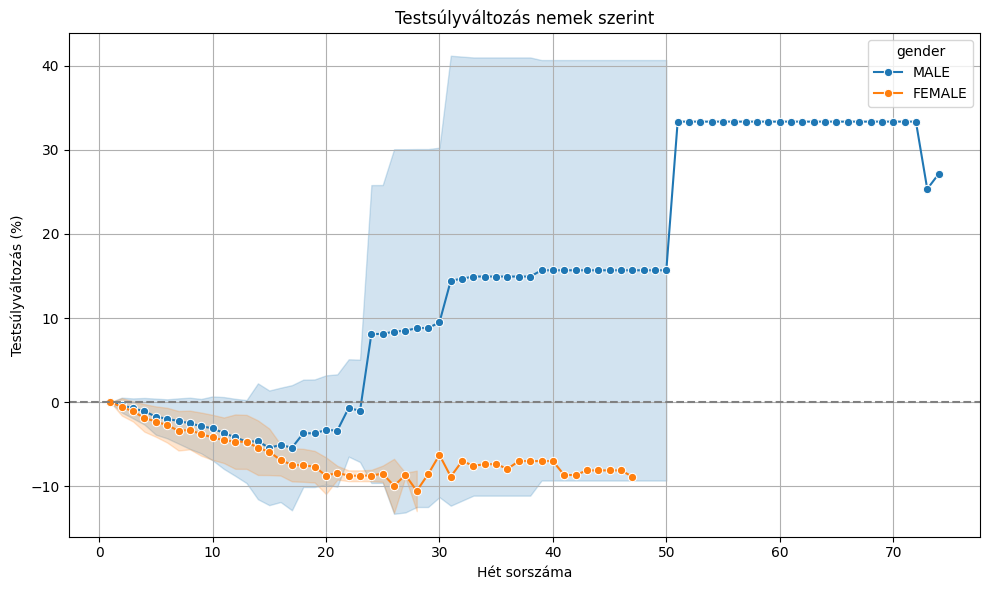

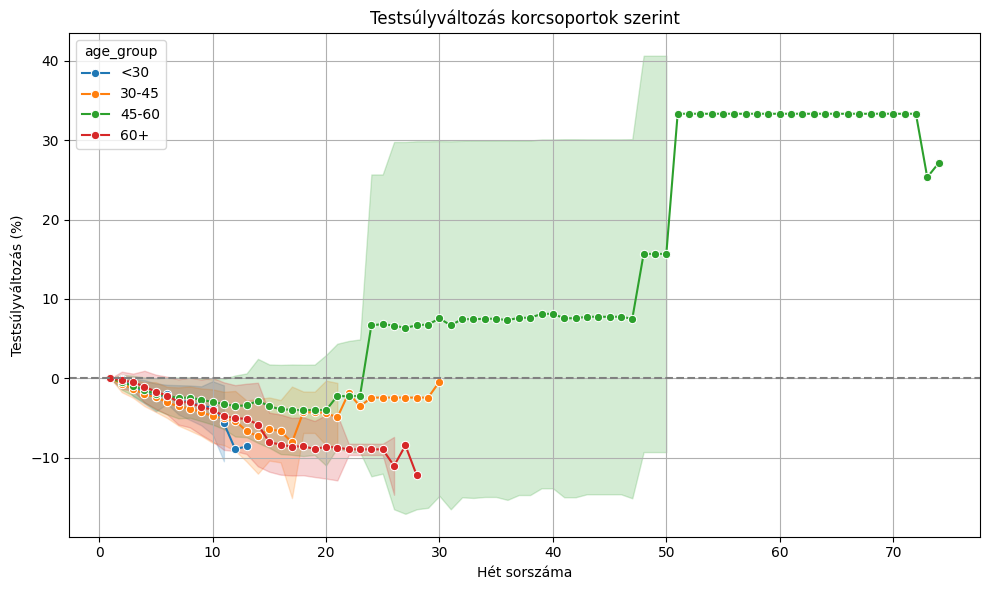

In [10]:
# Nemek és korcsoportok szerinti ábrák megjelenítése
plot_weight_loss_by_group(df_merged, "gender", "Testsúlyváltozás nemek szerint")
plot_weight_loss_by_group(df_merged, "age_group", "Testsúlyváltozás korcsoportok szerint")

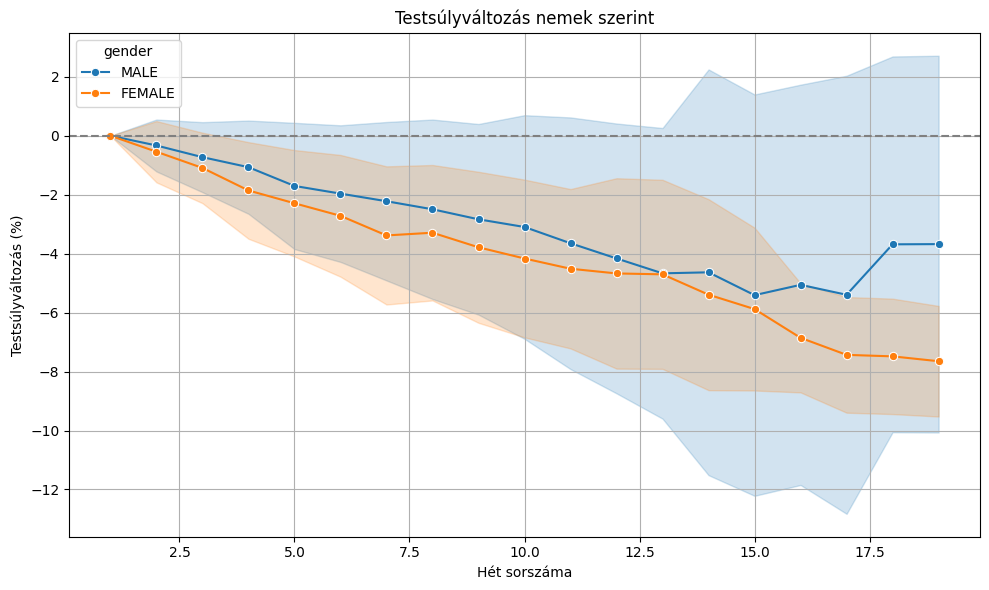

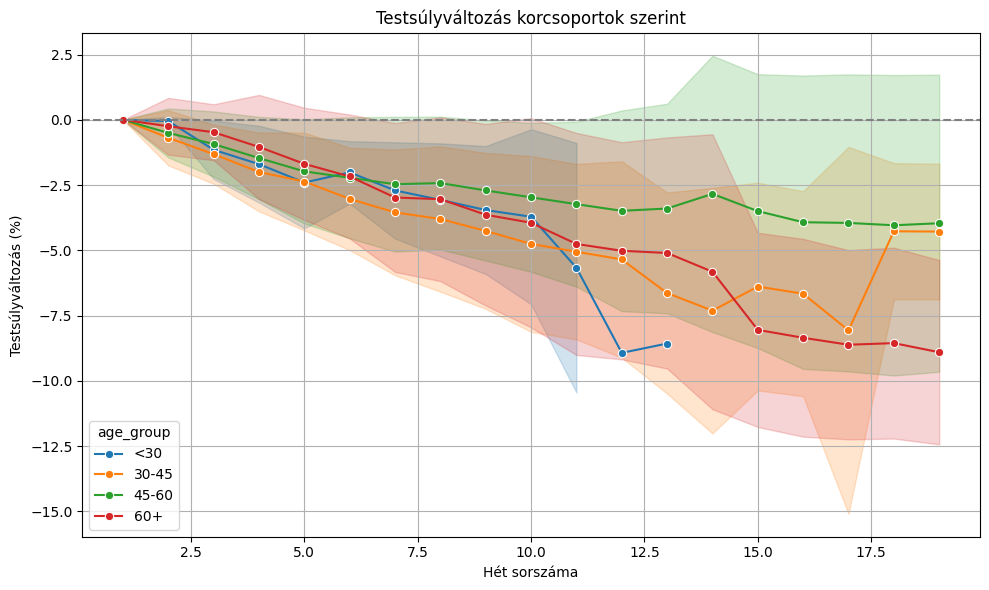

In [11]:
# dobjuk ki azt a pár pécienst aki már túl régóta van bent
df_merged_filt = df_merged.loc[df_merged['week_number']<20,:]
# Nemek és korcsoportok szerinti ábrák megjelenítése
plot_weight_loss_by_group(df_merged_filt, "gender", "Testsúlyváltozás nemek szerint")
plot_weight_loss_by_group(df_merged_filt, "age_group", "Testsúlyváltozás korcsoportok szerint")

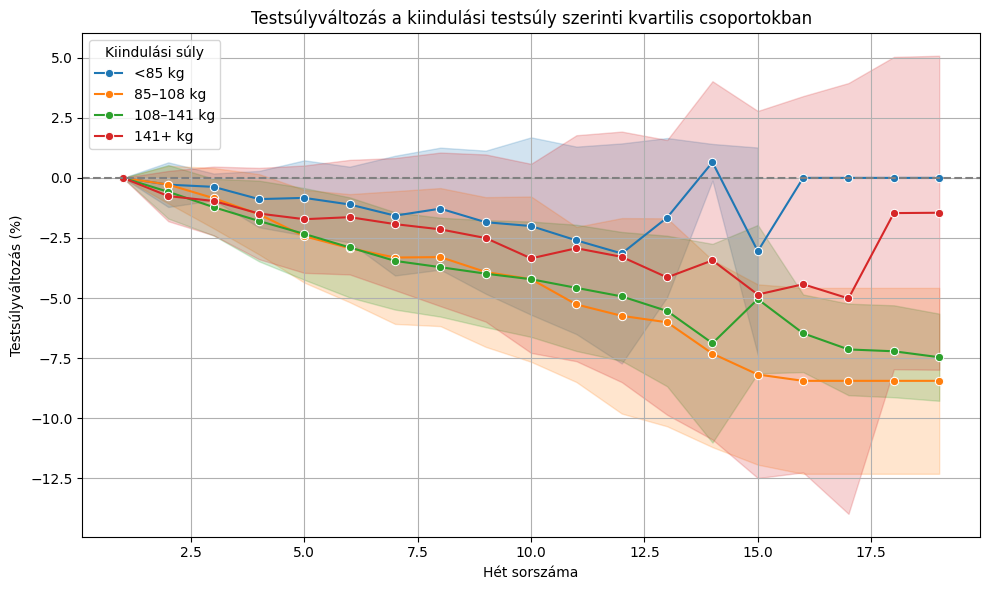

In [12]:
# Ábra újrarajzolása
plot_weight_loss_by_initial_weight_group(df_merged_filt)

In [13]:
# keressük meg minden páciens pénteki edzési eredményeit
df_exercise_weekly = (
                    df_exercise_results.groupby("patient_id")
                    .apply(resample_weekly_exercise_combined)
                    .reset_index()
                    .rename(columns={"ert_start_date": "timestamp", "activity_minutes": "num_of"})
                )

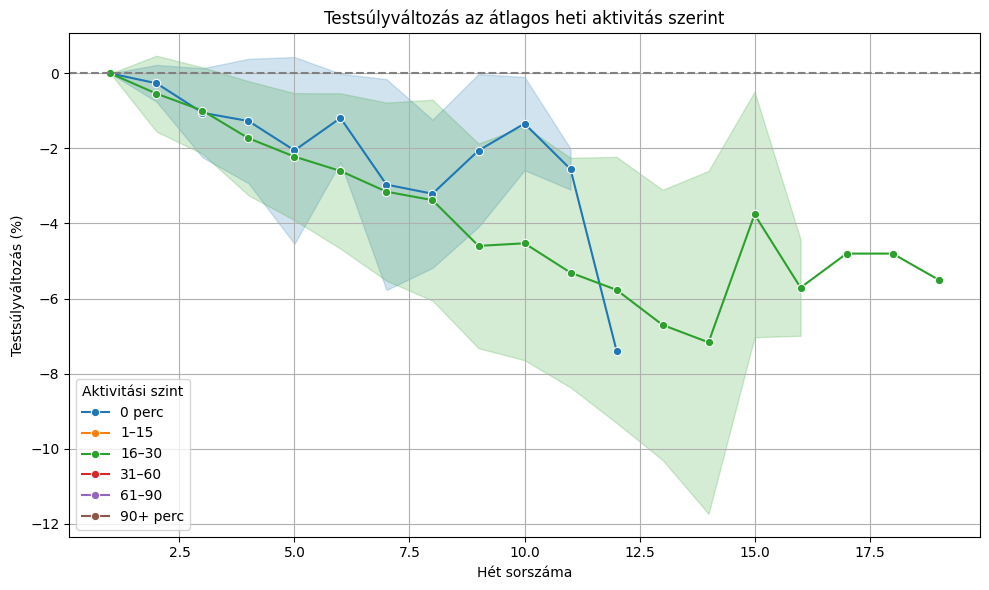

In [14]:
df_merged_with_activity = pd.merge(df_merged_filt, df_exercise_weekly,on=["patient_id",'timestamp'], how="left")

plot_weight_change_by_avg_activity(df_merged_with_activity, activity_col="average_weekly_activity_minutes")

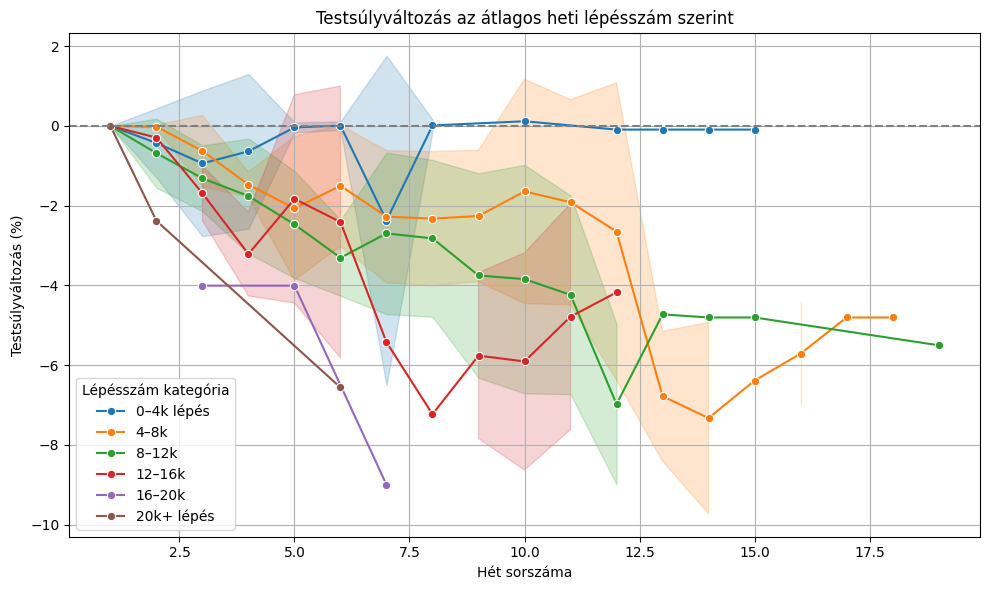

In [15]:
plot_weight_change_by_avg_steps_activity(df_merged_with_activity, activity_col='average_weekly_steps')